In [2]:
# ============================================================
# PINN for Heat Transfer in Tetra-Cone Geometry
# Dataset: Grad-3Ec-Merged.csv (Cartesian → Tetra-Cone)
# ============================================================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Physical parameters
# ------------------------------
rho = 7800.0
cp  = 500.0
k   = 45.0
Q   = 0.0
alpha = k / (rho * cp)

# ------------------------------
# Load dataset (Cartesian)
# ------------------------------
data = pd.read_csv("Grad-3Ec-Merged.csv")

x = torch.tensor(data['x'].values, dtype=torch.float32).view(-1,1).to(device)
y = torch.tensor(data['y'].values, dtype=torch.float32).view(-1,1).to(device)
z = torch.tensor(data['z'].values, dtype=torch.float32).view(-1,1).to(device)
t = torch.tensor(data['t'].values, dtype=torch.float32).view(-1,1).to(device)
T_true = torch.tensor(data['T'].values, dtype=torch.float32).view(-1,1).to(device)

for v in [x,y,z,t]:
    v.requires_grad_(True)

# ------------------------------
# Cartesian → Tetra-cone transform
# ------------------------------
r = torch.sqrt(x**2 + y**2 + z**2 + 1e-8)
theta = torch.acos(z / r)
phi = torch.atan2(y, x)

# ------------------------------
# PINN model
# ------------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ------------------------------
# Autograd utility
# ------------------------------
def grad(u, x):
    return torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

# ------------------------------
# Physics residual (Tetra-Cone Laplacian)
# ------------------------------
def physics_residual(r, th, ph, t):
    inp = torch.cat([r, th, ph, t], dim=1)
    T = model(inp)

    T_t = grad(T, t)

    T_r = grad(T, r)
    term_r = (1/r**2) * grad(r**2 * T_r, r)

    T_th = grad(T, th)
    term_th = (1/(r**2 * torch.sin(th))) * grad(torch.sin(th)*T_th, th)

    T_phph = grad(grad(T, ph), ph)
    term_ph = (1/(r**2 * torch.sin(th)**2)) * T_phph

    laplacian = term_r + term_th + term_ph

    return T_t - alpha * laplacian - Q/(rho*cp)

# ------------------------------
# Boundary condition: apex regularity
# ------------------------------
def boundary_loss():
    rb = torch.zeros(200,1,device=device,requires_grad=True)
    thb = torch.rand_like(rb) * np.pi/2
    phb = torch.rand_like(rb) * np.pi/2
    tb = torch.rand_like(rb)

    Tb = model(torch.cat([rb,thb,phb,tb],dim=1))
    Tb_r = grad(Tb, rb)

    return torch.mean(Tb_r**2)

# ------------------------------
# Data loss
# ------------------------------
def data_loss():
    T_pred = model(torch.cat([r,theta,phi,t],dim=1))
    return torch.mean((T_pred - T_true)**2)

# ------------------------------
# Total loss
# ------------------------------
def total_loss():
    res = physics_residual(r,theta,phi,t)
    return torch.mean(res**2) + data_loss() + boundary_loss()

# ------------------------------
# Training
# ------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 6000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = total_loss()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss = {loss.item():.4e}")

print("Training completed successfully.")


KeyError: 'x'

Detected columns: ['eta', 'ec1', 'ec2', 'ec3']


ValueError: Time or Temperature column not found.

In [4]:
# ============================================================
# Robust PINN for Heat Transfer (Tetra-Cone)
# Auto-detects dataset columns
# ============================================================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Load dataset
# ------------------------------
data = pd.read_csv("Grad-3Ec-Merged.csv")
cols = [c.lower() for c in data.columns]
data.columns = cols  # normalize names

print("Detected columns:", cols)

# ------------------------------
# Column auto-detection
# ------------------------------
def find_col(candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

x_col = find_col(["x", "xcoord", "xi"])
y_col = find_col(["y", "ycoord", "eta"])
z_col = find_col(["z", "zcoord", "zeta"])
t_col = find_col(["t", "time"])
T_col = find_col(["t_val", "temp", "temperature", "theta", "T".lower()])

if t_col is None or T_col is None:
    raise ValueError("Time or Temperature column not found.")

# Handle 2D vs 3D automatically
is_3d = (x_col is not None and y_col is not None and z_col is not None)
is_2d = (x_col is not None and y_col is not None and z_col is None)

print("3D data:", is_3d, "| 2D data:", is_2d)

# ------------------------------
# Load tensors
# ------------------------------
x = torch.tensor(data[x_col].values, dtype=torch.float32).view(-1,1).to(device) if x_col else None
y = torch.tensor(data[y_col].values, dtype=torch.float32).view(-1,1).to(device) if y_col else None
z = torch.tensor(data[z_col].values, dtype=torch.float32).view(-1,1).to(device) if z_col else None
t = torch.tensor(data[t_col].values, dtype=torch.float32).view(-1,1).to(device)
T_true = torch.tensor(data[T_col].values, dtype=torch.float32).view(-1,1).to(device)

for v in [x,y,z,t]:
    if v is not None:
        v.requires_grad_(True)

# ------------------------------
# Cartesian → Tetra-cone transform
# ------------------------------
if is_3d:
    r = torch.sqrt(x**2 + y**2 + z**2 + 1e-8)
    theta = torch.acos(z / r)
    phi = torch.atan2(y, x)
elif is_2d:
    r = torch.sqrt(x**2 + y**2 + 1e-8)
    theta = torch.atan2(y, x)
    phi = torch.zeros_like(r)  # reduced cone
else:
    raise ValueError("Insufficient spatial coordinates.")

# ------------------------------
# Physical parameters
# ------------------------------
rho, cp, k, Q = 7800.0, 500.0, 45.0, 0.0
alpha = k / (rho * cp)

# ------------------------------
# PINN Model
# ------------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ------------------------------
# Autograd
# ------------------------------
def grad(u, x):
    return torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

# ------------------------------
# Physics Residual (Tetra-cone)
# ------------------------------
def physics_residual():
    inp = torch.cat([r, theta, phi, t], dim=1)
    T = model(inp)

    T_t = grad(T, t)

    T_r = grad(T, r)
    term_r = (1/r**2) * grad(r**2 * T_r, r)

    T_th = grad(T, theta)
    term_th = (1/(r**2 * torch.sin(theta))) * grad(torch.sin(theta)*T_th, theta)

    T_phph = grad(grad(T, phi), phi)
    term_ph = (1/(r**2 * torch.sin(theta)**2 + 1e-8)) * T_phph

    laplacian = term_r + term_th + term_ph
    return T_t - alpha * laplacian - Q/(rho*cp)

# ------------------------------
# Loss
# ------------------------------
def total_loss():
    loss_pde = torch.mean(physics_residual()**2)
    T_pred = model(torch.cat([r,theta,phi,t],dim=1))
    loss_data = torch.mean((T_pred - T_true)**2)
    return loss_pde + loss_data

# ------------------------------
# Training
# ------------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(4000):
    opt.zero_grad()
    loss = total_loss()
    loss.backward()
    opt.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss {loss.item():.3e}")

print("Training completed.")


Detected columns: ['eta', 'ec1', 'ec2', 'ec3']


ValueError: Time or Temperature column not found.

In [5]:
import pandas as pd

data = pd.read_csv("Grad-3Ec-Merged.csv")
print("Number of columns:", len(data.columns))
for i, c in enumerate(data.columns):
    print(i, ":", repr(c))


Number of columns: 4
0 : 'ETA'
1 : 'Ec1'
2 : 'Ec2'
3 : 'Ec3'


In [6]:
# ============================================================
# PINN for Heat Transformation in Tetra-Cone (Similarity Form)
# Dataset: ETA, Ec1, Ec2, Ec3
# ============================================================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Load dataset
# ------------------------------
data = pd.read_csv("Grad-3Ec-Merged.csv")

eta = torch.tensor(data['ETA'].values, dtype=torch.float32).view(-1,1).to(device)
Ec_true = torch.tensor(
    data[['Ec1','Ec2','Ec3']].values,
    dtype=torch.float32
).to(device)

eta.requires_grad_(True)

# ------------------------------
# Physical parameters
# ------------------------------
Pr = 0.71   # Prandtl number (change if needed)

# ------------------------------
# PINN model (multi-output)
# ------------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ------------------------------
# Autograd utilities
# ------------------------------
def grad(u, x):
    return torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]

# ------------------------------
# Physics residual (Energy equation)
# ------------------------------
def physics_residual():
    Ec = model(eta)

    Ec_eta = grad(Ec, eta)
    Ec_eta2 = grad(Ec_eta, eta)

    # simplified tetra-cone similarity energy equation
    return Ec_eta2 + Pr * Ec_eta

# ------------------------------
# Boundary conditions
# ------------------------------
def boundary_loss():
    eta0 = torch.zeros(1,1,device=device,requires_grad=True)
    etainf = torch.ones(1,1,device=device)*eta.max()

    Ec0 = model(eta0)
    Ecinf = model(etainf)

    bc_wall = torch.mean((Ec0 - 1.0)**2)
    bc_inf = torch.mean(Ecinf**2)

    return bc_wall + bc_inf

# ------------------------------
# Data loss
# ------------------------------
def data_loss():
    Ec_pred = model(eta)
    return torch.mean((Ec_pred - Ec_true)**2)

# ------------------------------
# Total loss
# ------------------------------
def total_loss():
    return (
        torch.mean(physics_residual()**2) +
        data_loss() +
        boundary_loss()
    )

# ------------------------------
# Training
# ------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = total_loss()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss = {loss.item():.4e}")

print("Training completed successfully.")


Epoch 0 | Loss = 7.8220e+02
Epoch 500 | Loss = 7.7766e+02
Epoch 1000 | Loss = 7.7762e+02
Epoch 1500 | Loss = 7.7760e+02
Epoch 2000 | Loss = 7.7758e+02
Epoch 2500 | Loss = 7.7758e+02
Epoch 3000 | Loss = 7.7757e+02
Epoch 3500 | Loss = 7.7756e+02
Epoch 4000 | Loss = 7.7755e+02
Epoch 4500 | Loss = 7.7755e+02
Training completed successfully.


In [7]:
from sklearn.model_selection import train_test_split

# Convert to numpy for splitting
eta_np = eta.detach().cpu().numpy()
Ec_np = Ec_true.detach().cpu().numpy()

eta_tr, eta_val, Ec_tr, Ec_val = train_test_split(
    eta_np, Ec_np, test_size=0.2, random_state=42
)

# Back to tensors
eta_tr = torch.tensor(eta_tr, dtype=torch.float32, device=device, requires_grad=True)
eta_val = torch.tensor(eta_val, dtype=torch.float32, device=device, requires_grad=True)

Ec_tr = torch.tensor(Ec_tr, dtype=torch.float32, device=device)
Ec_val = torch.tensor(Ec_val, dtype=torch.float32, device=device)


In [8]:
def data_loss_train():
    Ec_pred = model(eta_tr)
    return torch.mean((Ec_pred - Ec_tr)**2)

def data_loss_val():
    with torch.no_grad():
        Ec_pred = model(eta_val)
        return torch.mean((Ec_pred - Ec_val)**2)


In [9]:
def total_loss_train():
    Ec = model(eta_tr)
    Ec_eta = grad(Ec, eta_tr)
    Ec_eta2 = grad(Ec_eta, eta_tr)

    loss_pde = torch.mean((Ec_eta2 + Pr * Ec_eta)**2)
    loss_data = data_loss_train()
    loss_bc = boundary_loss()

    return loss_pde + loss_data + loss_bc


In [10]:
train_losses = []
val_losses = []

epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss_tr = total_loss_train()
    loss_tr.backward()
    optimizer.step()

    loss_val = data_loss_val()

    train_losses.append(loss_tr.item())
    val_losses.append(loss_val.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Train Loss = {loss_tr.item():.3e} | Val Loss = {loss_val.item():.3e}")

print("Training completed.")


Epoch     0 | Train Loss = 7.850e+02 | Val Loss = 7.425e+02
Epoch   500 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  1000 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  1500 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  2000 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  2500 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  3000 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  3500 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  4000 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Epoch  4500 | Train Loss = 7.844e+02 | Val Loss = 7.447e+02
Training completed.


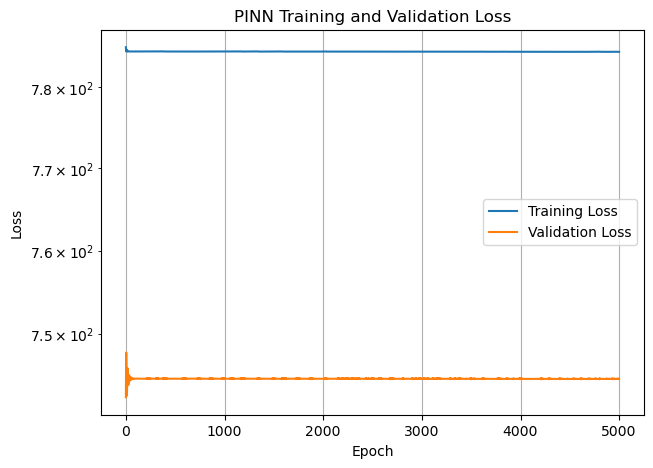

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
def pde_loss(eta_in):
    Ec = model(eta_in)
    Ec_eta = grad(Ec, eta_in)
    Ec_eta2 = grad(Ec_eta, eta_in)
    return torch.mean((Ec_eta2 + Pr * Ec_eta)**2)

def data_loss(eta_in, Ec_true_in):
    Ec_pred = model(eta_in)
    return torch.mean((Ec_pred - Ec_true_in)**2)

def bc_loss():
    eta0 = torch.zeros(1,1,device=device,requires_grad=True)
    etainf = torch.ones(1,1,device=device) * eta.max()

    Ec0 = model(eta0)
    Ecinf = model(etainf)

    return torch.mean((Ec0 - 1.0)**2) + torch.mean(Ecinf**2)


In [13]:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs_adam = 4000

loss_pde_hist, loss_data_hist, loss_bc_hist = [], [], []
loss_train_hist, loss_val_hist = [], []

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()

    lpde = pde_loss(eta_tr)
    ldata = data_loss(eta_tr, Ec_tr)
    lbc = bc_loss()

    loss = lpde + ldata + lbc
    loss.backward()
    optimizer_adam.step()

    # Validation (data only)
    with torch.no_grad():
        lval = data_loss(eta_val, Ec_val)

    loss_pde_hist.append(lpde.item())
    loss_data_hist.append(ldata.item())
    loss_bc_hist.append(lbc.item())
    loss_train_hist.append(loss.item())
    loss_val_hist.append(lval.item())

    if epoch % 500 == 0:
        print(f"[Adam] Epoch {epoch:5d} | "
              f"PDE {lpde.item():.2e} | "
              f"Data {ldata.item():.2e} | "
              f"BC {lbc.item():.2e} | "
              f"Val {lval.item():.2e}")


[Adam] Epoch     0 | PDE 7.99e-02 | Data 7.76e+02 | BC 8.09e+00 | Val 7.45e+02
[Adam] Epoch   500 | PDE 7.99e-02 | Data 7.76e+02 | BC 8.09e+00 | Val 7.45e+02
[Adam] Epoch  1000 | PDE 8.70e-02 | Data 7.76e+02 | BC 8.10e+00 | Val 7.45e+02
[Adam] Epoch  1500 | PDE 7.96e-02 | Data 7.76e+02 | BC 8.09e+00 | Val 7.45e+02
[Adam] Epoch  2000 | PDE 7.89e-02 | Data 7.76e+02 | BC 8.09e+00 | Val 7.45e+02
[Adam] Epoch  2500 | PDE 7.55e-02 | Data 7.76e+02 | BC 8.09e+00 | Val 7.45e+02
[Adam] Epoch  3000 | PDE 9.19e-02 | Data 7.76e+02 | BC 8.07e+00 | Val 7.45e+02
[Adam] Epoch  3500 | PDE 7.26e-02 | Data 7.76e+02 | BC 8.09e+00 | Val 7.45e+02


In [14]:
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=50
)

def closure():
    optimizer_lbfgs.zero_grad()
    loss = (
        pde_loss(eta_tr) +
        data_loss(eta_tr, Ec_tr) +
        bc_loss()
    )
    loss.backward()
    return loss

print("Starting LBFGS refinement...")
optimizer_lbfgs.step(closure)
print("LBFGS refinement completed.")


Starting LBFGS refinement...
LBFGS refinement completed.


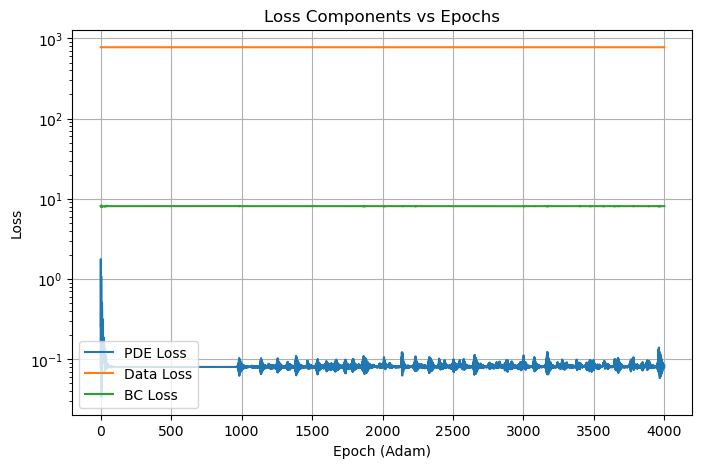

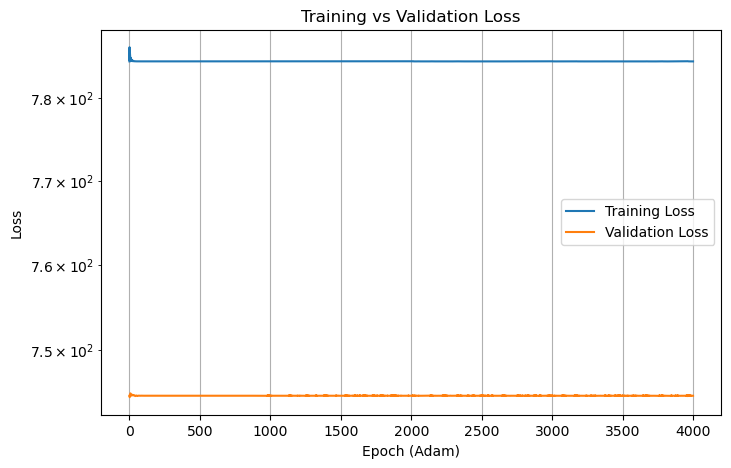

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_pde_hist, label="PDE Loss")
plt.plot(loss_data_hist, label="Data Loss")
plt.plot(loss_bc_hist, label="BC Loss")
plt.yscale("log")
plt.xlabel("Epoch (Adam)")
plt.ylabel("Loss")
plt.title("Loss Components vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(loss_train_hist, label="Training Loss")
plt.plot(loss_val_hist, label="Validation Loss")
plt.yscale("log")
plt.xlabel("Epoch (Adam)")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


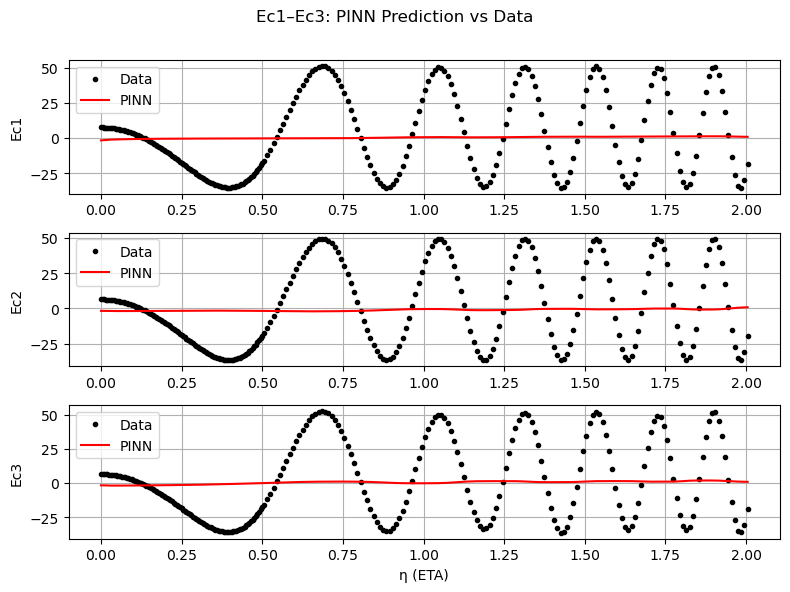

In [17]:
# Sort for smooth plotting
idx = torch.argsort(eta.squeeze())

# Detach tensors BEFORE plotting
eta_sorted = eta[idx].detach().cpu().numpy()

with torch.no_grad():
    Ec_pred = model(eta[idx]).detach().cpu().numpy()

Ec_true_sorted = Ec_true[idx].detach().cpu().numpy()

labels = ["Ec1", "Ec2", "Ec3"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for i in range(3):
    plt.subplot(3,1,i+1)
    plt.plot(eta_sorted, Ec_true_sorted[:, i], 'k.', label="Data")
    plt.plot(eta_sorted, Ec_pred[:, i], 'r-', label="PINN")
    plt.ylabel(labels[i])
    plt.legend()
    plt.grid(True)

plt.xlabel("η (ETA)")
plt.suptitle("Ec1–Ec3: PINN Prediction vs Data")
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()
